# EDA

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('IMDB-Movie-Data.csv')

In [4]:
data.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


In [5]:
data.shape

(1000, 12)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


In [7]:
data.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


In [8]:
data.isnull().sum()

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

Heatmap

<Axes: >

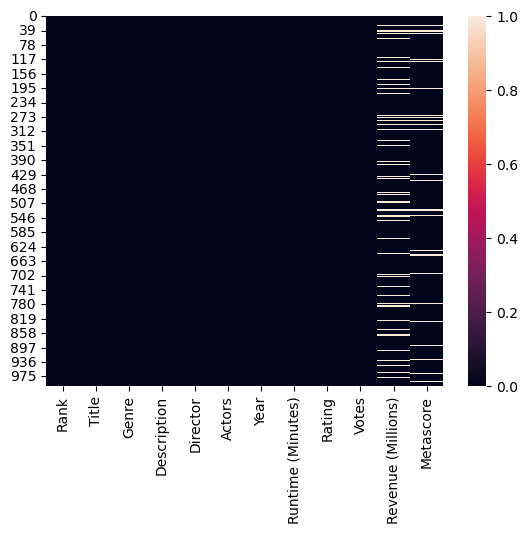

In [9]:
sns.heatmap(data.isnull())

Percentage of missing data 

In [10]:
per_missing = data.isnull().sum() * 100 / len(data)

In [11]:
per_missing

Rank                   0.0
Title                  0.0
Genre                  0.0
Description            0.0
Director               0.0
Actors                 0.0
Year                   0.0
Runtime (Minutes)      0.0
Rating                 0.0
Votes                  0.0
Revenue (Millions)    12.8
Metascore              6.4
dtype: float64

In [12]:
data.dropna(axis=0, how='any', inplace=True)  # Dropping rows with any missing values

In [13]:
data.shape

(838, 12)

Duplicates

In [16]:
data.duplicated().any() # Check for duplicate rows

np.False_

Fetch a data based on a condition

In [22]:
data['Runtime (Minutes)'] >= 180 # Returns a boolean series for movies with runtime greater than or equal to 180 minutes

0      False
1      False
2      False
3      False
4      False
       ...  
993    False
994    False
996    False
997    False
999    False
Name: Runtime (Minutes), Length: 838, dtype: bool

In [23]:
data[data['Runtime (Minutes)'] >= 180] # Returns rows for movies with runtime greater than or equal to 180 minutes

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
82,83,The Wolf of Wall Street,"Biography,Comedy,Crime","Based on the true story of Jordan Belfort, fro...",Martin Scorsese,"Leonardo DiCaprio, Jonah Hill, Margot Robbie,M...",2013,180,8.2,865134,116.87,75.0
88,89,The Hateful Eight,"Crime,Drama,Mystery","In the dead of a Wyoming winter, a bounty hunt...",Quentin Tarantino,"Samuel L. Jackson, Kurt Russell, Jennifer Jaso...",2015,187,7.8,341170,54.12,68.0
311,312,La vie d'Adèle,"Drama,Romance","Adèle's life is changed when she meets Emma, a...",Abdellatif Kechiche,"Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...",2013,180,7.8,103150,2.20,88.0


In [24]:
data[data['Runtime (Minutes)'] >= 180]['Title'] # Returns titles of movies with runtime greater than or equal to 180 minutes

82     The Wolf of Wall Street
88           The Hateful Eight
311             La vie d'Adèle
Name: Title, dtype: object

In [25]:
data[data['Runtime (Minutes)'] >= 180][['Title', 'Runtime (Minutes)']] # Returns titles and runtimes of movies with runtime greater than or equal to 180 minutes

,Title,Runtime (Minutes)
82,The Wolf of Wall Street,180
88,The Hateful Eight,187
311,La vie d'Adèle,180


Year vs Voting -> Highest average (In graph)

In [30]:
data.groupby('Year')['Votes'].mean().sort_values(ascending=False)    # Average number of votes per year

Year
2012    290861.483871
2006    277232.219512
2009    267180.577778
2008    266580.145833
2007    266530.704545
2010    261082.929825
2011    259254.736842
2013    225531.892857
2014    211926.881720
2015    129512.651376
2016     68437.823232
Name: Votes, dtype: float64

<Axes: xlabel='Year', ylabel='Votes'>

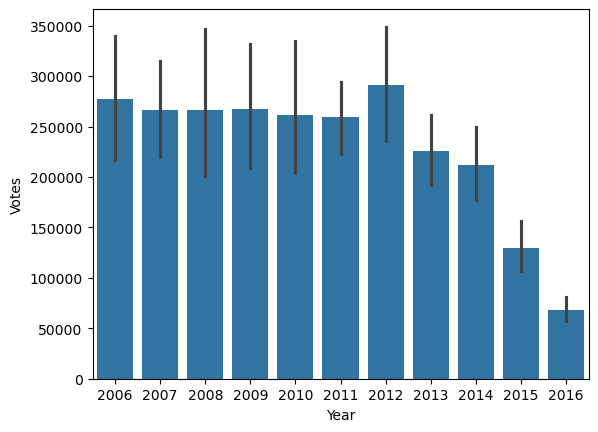

In [32]:
sns.barplot(x='Year', y='Votes', data=data) # Bar plot of average votes per year

In [39]:
data.groupby('Rating')['Year'].mean().sort_values(ascending=False)

Rating
4.0    2016.000000
3.9    2016.000000
4.6    2015.500000
4.1    2015.000000
5.3    2014.625000
6.3    2014.361111
5.4    2014.100000
5.7    2014.062500
5.1    2014.000000
6.0    2013.800000
8.6    2013.666667
4.9    2013.500000
7.4    2013.379310
5.9    2013.200000
5.8    2013.190476
6.5    2013.057143
4.7    2013.000000
4.8    2013.000000
6.1    2013.000000
6.2    2012.787879
7.1    2012.750000
6.7    2012.738095
5.6    2012.692308
4.3    2012.666667
6.9    2012.478261
7.5    2012.424242
6.8    2012.424242
7.2    2012.421053
8.1    2012.416667
7.9    2012.400000
7.0    2012.372093
7.3    2012.270270
8.2    2012.111111
6.4    2012.100000
6.6    2011.648649
7.8    2011.447368
8.0    2011.421053
7.6    2011.384615
8.3    2011.200000
5.2    2010.833333
7.7    2010.760000
8.4    2010.500000
5.5    2010.454545
8.8    2010.000000
2.7    2009.000000
4.4    2009.000000
8.5    2008.500000
1.9    2008.000000
5.0    2008.000000
9.0    2008.000000
Name: Year, dtype: float64

<Axes: xlabel='Year', ylabel='Rating'>

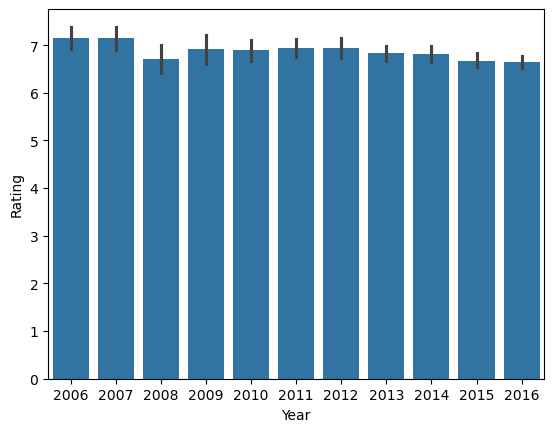

In [40]:
sns.barplot(x='Year', y='Rating', data=data) # Bar plot of average rating per year

Top 10 lengthy movies title along with runctime

In [43]:
top10_len= data.nlargest(10, 'Runtime (Minutes)')[['Title','Rating','Runtime (Minutes)']] # Returns top 10 longest movies with their titles and ratings

In [42]:
top10_len

,Title,Rating,Runtime (Minutes)
88,The Hateful Eight,7.8,187
82,The Wolf of Wall Street,8.2,180
311,La vie d'Adèle,7.8,180
267,Cloud Atlas,7.5,172
430,3 Idiots,8.4,170
36,Interstellar,8.6,169
75,Pirates of the Caribbean: At World's End,7.1,169
271,The Hobbit: An Unexpected Journey,7.9,169
425,The Curious Case of Benjamin Button,7.8,166
126,Transformers: Age of Extinction,5.7,165


In [44]:
top10_len= data.nlargest(10, 'Runtime (Minutes)')[['Title','Rating','Runtime (Minutes)']].set_index('Title') # Sets 'Title' as index for better visualization

In [45]:
top10_len

,Rating,Runtime (Minutes)
Title,,
The Hateful Eight,7.8,187
The Wolf of Wall Street,8.2,180
La vie d'Adèle,7.8,180
Cloud Atlas,7.5,172
3 Idiots,8.4,170
Interstellar,8.6,169
Pirates of the Caribbean: At World's End,7.1,169
The Hobbit: An Unexpected Journey,7.9,169
The Curious Case of Benjamin Button,7.8,166


<Axes: xlabel='Runtime (Minutes)', ylabel='Title'>

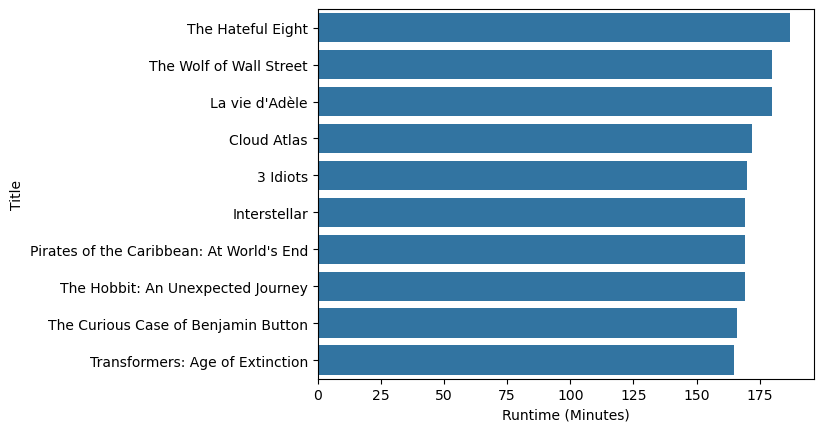

In [47]:
sns.barplot(x = 'Runtime (Minutes)', y = top10_len.index, data=top10_len) # Bar plot of top 10 longest movies

Get the maximum values

In [48]:
data[data['Revenue (Millions)'].max() == data['Revenue (Millions)']]['Title'] # Returns title of the movie with highest revenue

50    Star Wars: Episode VII - The Force Awakens
Name: Title, dtype: object

Top 10 highest rated movies and its directors

In [53]:
top10_rate = data.nlargest(10, 'Rating')[['Title','Rating','Director']].set_index('Title') # Returns top 2 highest rated movies with their titles and directors

In [54]:
top10_rate

,Rating,Director
Title,,
The Dark Knight,9.0,Christopher Nolan
Inception,8.8,Christopher Nolan
Interstellar,8.6,Christopher Nolan
Kimi no na wa,8.6,Makoto Shinkai
The Intouchables,8.6,Olivier Nakache
The Prestige,8.5,Christopher Nolan
The Departed,8.5,Martin Scorsese
The Dark Knight Rises,8.5,Christopher Nolan
Whiplash,8.5,Damien Chazelle


<Axes: xlabel='Rating', ylabel='Title'>

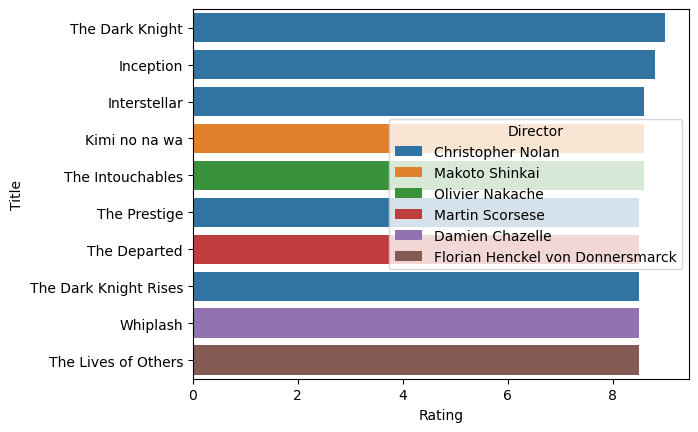

In [60]:
sns.barplot(
    x='Rating',
    y=top10_rate.index,
    data=top10_rate,
    orient='h',
    hue='Director',
)